In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score
from sklearn.model_selection import LeaveOneOut,KFold
from itertools import product

In [ ]:
data = pd.read_excel('Microwave_Pyrolysis_Dataset.xlsx')
data = data.drop(columns = ['No.','Ref', 'Biomass','Catalyst'])

X= data.drop(['Gas yield','Oil yield', 'Char yield'], axis =1, inplace = False)
y = data['Gas yield']

In [ ]:
para = {
    'n_estimators': [ 100,150],
    'max_depth': [4,10],
    'min_samples_split': [2,4],
    'min_samples_leaf': [1,2]
}

para_comb = list(product(para['n_estimators'],para['max_depth'],para['min_samples_split'],para['min_samples_leaf']))

In [ ]:
mse_hist =[]
bmse = float('inf')
best_para = None

for n_estimators,max_depth,min_samples_split,min_samples_leaf in para_comb:
    model = GradientBoostingRegressor(n_estimators=n_estimators,
                                      max_depth=max_depth,
                                      min_samples_split=min_samples_split,
                                      min_samples_leaf=min_samples_leaf,
                                      learning_rate =0.1,
                                      random_state=42)

    loo = LeaveOneOut()
    mse_hist = []

    for train_idx,test_idx in loo.split(y):
      x_train,y_train,x_test,y_test = X.iloc[train_idx],y.iloc[train_idx],X.iloc[test_idx],y.iloc[test_idx]

      model.fit(x_train,y_train)

      y_pred = model.predict(x_test)
      mse= mean_squared_error(y_pred,y_test)
      mse_hist.append(mse)

    mse = np.mean(mse_hist)

    if mse<bmse:
      bmse = mse
      best_para = {'n_estimators':n_estimators,
                   'max_depth':max_depth,
                   'min_samples_split':min_samples_split,
                   'min_samples_leaf':min_samples_leaf
      }



{'n_estimators': 150, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 1}
MSE: 9.82820556318447
MAE: 1.7336890364924338
R2: 0.9575641490599779


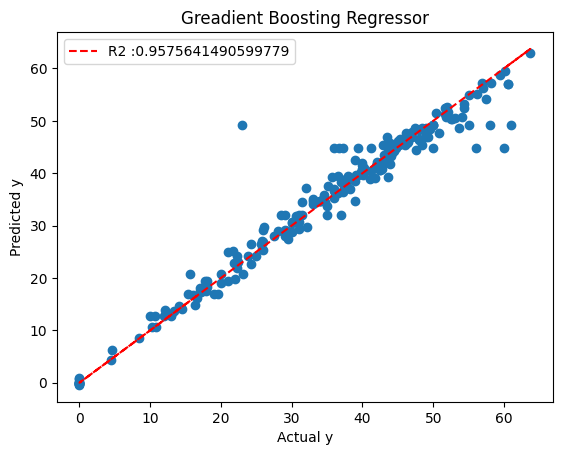

In [ ]:
best_model = GradientBoostingRegressor(**best_para,learning_rate=0.1,random_state =42)

best_model.fit(X,y)
y_pred =best_model.predict(X)

mse = mean_squared_error(y,y_pred)
mae = mean_absolute_error(y,y_pred)
r2 = r2_score(y,y_pred)

print(best_para)
print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')

plt.plot(y,y,'r--',label = 'Ideal')
plt.scatter(y,y_pred,label ='Predicted')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title('Greadient Boosting Regressor')
plt.legend([f'R2 :{r2}'])
plt.show()